In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
import os

os.listdir("/kaggle/input/chest-xray-pneumonia")

['chest_xray']

In [4]:
os.listdir("/kaggle/input/chest-xray-pneumonia/chest_xray")

['chest_xray', '__MACOSX', 'val', 'test', 'train']

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode="binary"
)
val_generator = test_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/val",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode="binary"
)
test_generator = test_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/test",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(256,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=["accuracy"])

In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [9]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8403 - loss: 2.3431 - val_accuracy: 0.5000 - val_loss: 69.1302
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 724ms/step - accuracy: 0.9185 - loss: 0.2392 - val_accuracy: 0.5000 - val_loss: 45.9523
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 792ms/step - accuracy: 0.9020 - loss: 0.2891 - val_accuracy: 0.5000 - val_loss: 47.2075
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.9303 - loss: 0.1713 - val_accuracy: 0.6250 - val_loss: 0.7980
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 141s 865ms/step - accuracy: 0.9317 - loss: 0.1872 - val_accuracy: 0.6250 - val_loss: 1.8955
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 144s 883ms/step - accuracy: 0.9256 - loss: 0.2147 - val_accuracy: 0.6250 - val_loss: 0.9740
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 144s 882ms/step - accuracy: 0.9363 - loss: 0.1693 - val_accuracy: 0.6250 - val_loss: 3.2113
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 832ms/step - accuracy: 0.9392 - lo

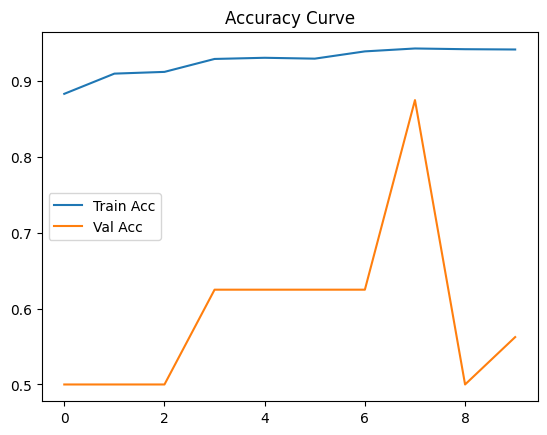

In [10]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"],label="Train Acc")
plt.plot(history.history["val_accuracy"],label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

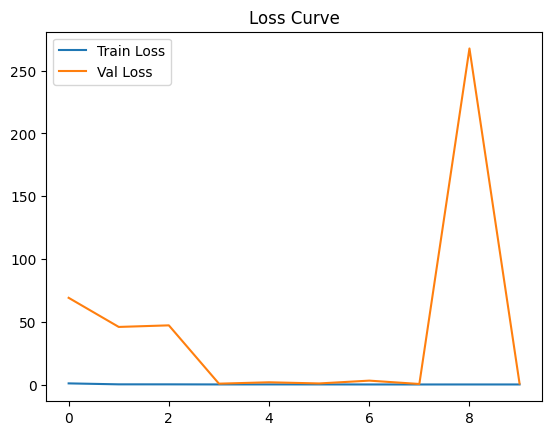

In [11]:
plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [12]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:",test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 322ms/step - accuracy: 0.8667 - loss: 0.2969
Test Accuracy: 0.7916666865348816


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
preds = model.predict(test_generator)
pred_labels = (preds>0.5).astype(int)
cm = confusion_matrix(test_generator.classes,pred_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step


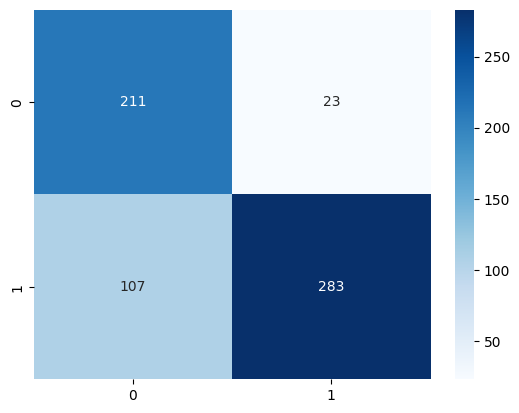

In [14]:
import seaborn as sns
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.show()

In [15]:
print(classification_report(test_generator.classes,pred_labels))

              precision    recall  f1-score   support

           0       0.66      0.90      0.76       234
           1       0.92      0.73      0.81       390

    accuracy                           0.79       624
   macro avg       0.79      0.81      0.79       624
weighted avg       0.83      0.79      0.79       624



In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [17]:
base_model = MobileNetV2(weights="imagenet",
                         include_top=False,
                         input_shape=(224,224,3))
base_model.trainable=False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
model = Sequential([
    base_model, GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

In [19]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 190s 998ms/step - accuracy: 0.5575 - loss: 0.7628 - val_accuracy: 0.7500 - val_loss: 0.5415
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 785ms/step - accuracy: 0.7274 - loss: 0.5517 - val_accuracy: 0.8125 - val_loss: 0.4481
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.7959 - loss: 0.4331 - val_accuracy: 0.8750 - val_loss: 0.3994
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 664ms/step - accuracy: 0.8198 - loss: 0.3931 - val_accuracy: 0.8750 - val_loss: 0.3715
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 653ms/step - accuracy: 0.8432 - loss: 0.3511 - val_accuracy: 0.8750 - val_loss: 0.3549


In [21]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:",test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 214ms/step - accuracy: 0.8197 - loss: 0.4285
Test Accuracy: 0.8589743375778198


In [23]:
base_model.trainable = True

In [24]:
for layer in base_model.layers[:20]:
  layer.trainable=False

In [25]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [26]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 705ms/step - accuracy: 0.7734 - loss: 0.4745 - val_accuracy: 0.6250 - val_loss: 0.7485
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 664ms/step - accuracy: 0.9271 - loss: 0.1939 - val_accuracy: 0.5625 - val_loss: 1.1603
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 665ms/step - accuracy: 0.9492 - loss: 0.1319 - val_accuracy: 0.5625 - val_loss: 1.4486
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 665ms/step - accuracy: 0.9548 - loss: 0.1216 - val_accuracy: 0.5625 - val_loss: 1.3667
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 674ms/step - accuracy: 0.9595 - loss: 0.0999 - val_accuracy: 0.5000 - val_loss: 1.5781


20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 451ms/step


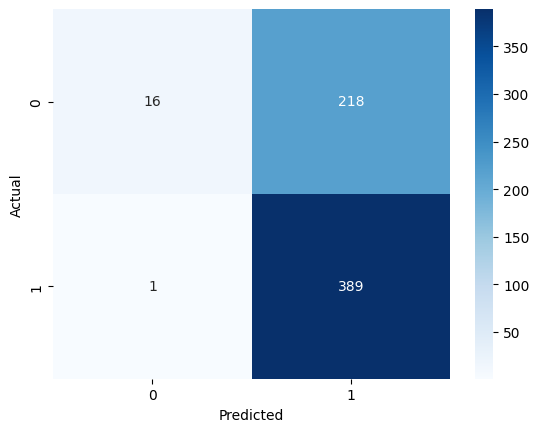

              precision    recall  f1-score   support

           0       0.94      0.07      0.13       234
           1       0.64      1.00      0.78       390

    accuracy                           0.65       624
   macro avg       0.79      0.53      0.45       624
weighted avg       0.75      0.65      0.54       624



In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

preds = model.predict(test_generator)
pred_labels = (preds > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, pred_labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(test_generator.classes, pred_labels))

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = test_generator.filepaths[0]  # first test image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [29]:
last_conv_layer = base_model.get_layer("Conv_1")

In [30]:
import tensorflow as tf

grad_model = tf.keras.models.Model(
    [model.inputs],
    [last_conv_layer.output, model.output]
)

AttributeError: The layer sequential_1 has never been called and thus has no defined output.

In [31]:
model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


array([[0.9721018]], dtype=float32)

In [32]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Input

inputs = Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

In [33]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [34]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)

Epoch 1/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 177s 826ms/step - accuracy: 0.9016 - loss: 0.2055 - val_accuracy: 0.8125 - val_loss: 0.3130
Epoch 2/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 674ms/step - accuracy: 0.9730 - loss: 0.0656 - val_accuracy: 0.9375 - val_loss: 0.1831


In [35]:
import tensorflow as tf

last_conv_layer = base_model.get_layer("Conv_1")

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[last_conv_layer.output, model.output]
)

In [36]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = test_generator.filepaths[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)